## Initial

In [2]:
# packages
# database & data Manipulation
import sqlite3
import pandas as pd
import numpy as np

# visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio

# modeling & statistics
import sklearn as skl
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import statsmodels.api as stats

# application & formatting output
from tabulate import tabulate
import streamlit as st

---

## SQL DB Connect & Clean Nulls

In [35]:
# connect to SQLite database and inspect traits table
conn = sqlite3.connect("../sql/fish_species_project.db")
df = pd.read_sql("SELECT * FROM fish_species_traits;", conn)

print(df.head())
print(df.info())
print(df.describe())

   SpecCode              Genus                     Species  \
0     64588  Aapticheilichthys  Aapticheilichthys websteri   
1     16239          Aaptosyax            Aaptosyax grypus   
2      2347      Abactochromis      Abactochromis labrosus   
3     62612          Abalistes      Abalistes filamentosus   
4         9          Abalistes         Abalistes stellatus   

               FBname  Length LTypeMaxM        Weight           BodyShapeI  \
0                 NaN    3.08        SL  46243.196613    fusiform / normal   
1   Giant salmon carp  130.00        SL  30000.000000    fusiform / normal   
2                 NaN   11.50        SL  46243.196613  short and / or deep   
3                 NaN   32.50        SL   1375.000000  short and / or deep   
4  Starry triggerfish   60.00        TL  46243.196613  short and / or deep   

   Fresh  Brack  ...  IUCN_Code Resilience Vulnerability      Aquarium  \
0      1      0  ...         NE     Unkwon         10.00  never/rarely   
1      1  

In [36]:
# check for nulls
print(df.isnull().sum())

SpecCode                  0
Genus                     0
Species                   0
FBname                18113
Length                    0
LTypeMaxM                 0
Weight                    0
BodyShapeI                4
Fresh                     0
Brack                     0
Saltwater                 0
DemersPelag               0
IUCN_Code               236
Resilience                0
Vulnerability             2
Aquarium                  0
GameFish                  0
Importance                0
UsedforAquaculture        0
SizeClass                 0
CommercialStatus          0
ThreatenedStatus          0
dtype: int64


In [37]:
# drop high-null metadata column and impute missing values
df = df.drop(columns=["FBname"])

df["BodyShapeI"] = df["BodyShapeI"].fillna("Unknown")
df["IUCN_Code"] = df["IUCN_Code"].fillna("Unknown")
df["Vulnerability"] = df["Vulnerability"].fillna(df["Vulnerability"].median())

In [38]:
# verify
print(df.isnull().sum())

SpecCode              0
Genus                 0
Species               0
Length                0
LTypeMaxM             0
Weight                0
BodyShapeI            0
Fresh                 0
Brack                 0
Saltwater             0
DemersPelag           0
IUCN_Code             0
Resilience            0
Vulnerability         0
Aquarium              0
GameFish              0
Importance            0
UsedforAquaculture    0
SizeClass             0
CommercialStatus      0
ThreatenedStatus      0
dtype: int64


---

## Exploratory Data Analysis (EDA)

### Heatmap

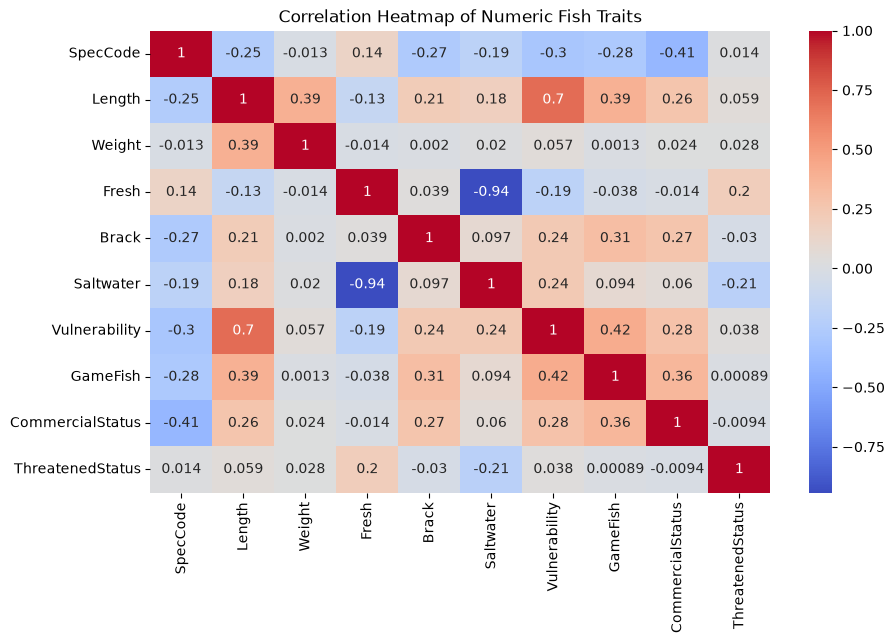

In [39]:
# select only numeric columns
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# create the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap of Numeric Fish Traits")
plt.show()

### Length v Weight Scatterplot

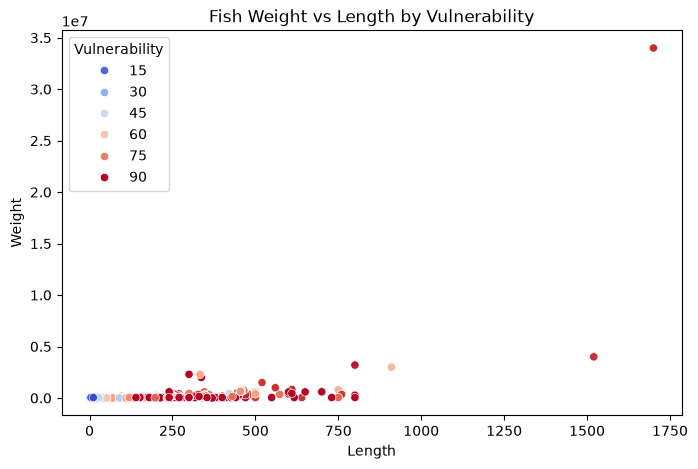

In [40]:
# visualize length vs. weight relationship colored by vulnerability score
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Length", y="Weight", hue="Vulnerability", palette="coolwarm")
plt.title("Fish Weight vs Length by Vulnerability")
plt.show()

### Distribution of Fish Length

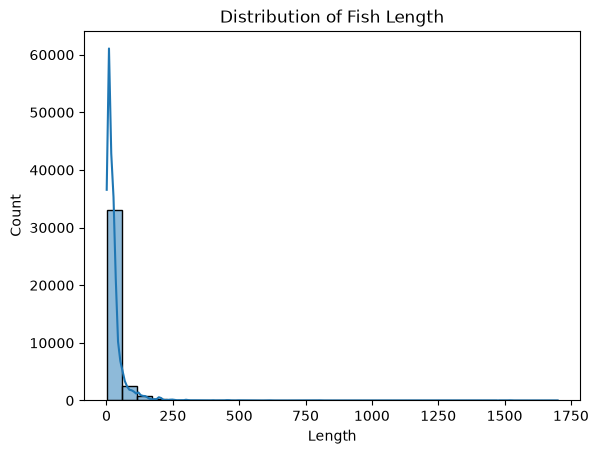

In [41]:
#plot the distribution of fish length with kernel density estimation
sns.histplot(df["Length"], bins=30, kde=True)
plt.title("Distribution of Fish Length")
plt.xlabel("Length")
plt.ylabel("Count")
plt.show()

---

## Statistical Modeling & Ordinary Least Squares (OLS)

In [42]:
# fit Ordinary Least Squares (OLS) model to examine feature coefficients and significance
x_stats = df[["Weight", "Vulnerability", "Fresh", "Brack", "Saltwater"]]
x_stats = stats.add_constant(x_stats)
y_stats = df["Length"]

ols_model = stats.OLS(y_stats, x_stats).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Length   R-squared:                       0.625
Model:                            OLS   Adj. R-squared:                  0.625
Method:                 Least Squares   F-statistic:                 1.229e+04
Date:                Tue, 25 Aug 2026   Prob (F-statistic):               0.00
Time:                        11:40:36   Log-Likelihood:            -1.7760e+05
No. Observations:               36856   AIC:                         3.552e+05
Df Residuals:                   36850   BIC:                         3.553e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const           -24.8652      1.028    -24.197

## Key OLS & Model Interpretation Notes

- **Variance Explained ($R^2 = 0.625$)**: The baseline linear model accounts for ~62.5% of the variance in fish length using physical traits and habitat flags.
- **Feature Significance**: All predictors (`Weight`, `Vulnerability`, `Fresh`, `Brack`, `Saltwater`) demonstrate statistically significant $p$-values ($p < 0.001$).
- **Vulnerability Impact**: For every unit increase in vulnerability score, predicted species length increases by approximately 1.88 cm, holding other traits constant.
- **Cross-Validation Residuals**: The variance in 5-Fold Cross-Validation ($R^2 = -0.3870$) highlights non-linear scaling dynamics between weight and length across diverse taxonomies, indicating log-transformation would optimize future iterations.

---

## Machine Learning & Model Evaluation

### Linear Regression with K-Fold Cross-Validation

In [43]:
# define features and target variable
features = ["Weight", "Vulnerability", "Fresh", "Brack", "Saltwater"]
x = df[features]
y = df["Length"]

# train-test split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# perform 5-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
lr_model = LinearRegression()

cv_r2 = cross_val_score(lr_model, x, y, cv=kf, scoring='r2')
cv_rmse = np.sqrt(-cross_val_score(lr_model, x, y, cv=kf, scoring='neg_mean_squared_error'))

print(f"5-Fold CV R2 Score: {cv_r2.mean():.4f} (+/- {cv_r2.std():.4f})")
print(f"5-Fold CV RMSE: {cv_rmse.mean():.4f} (+/- {cv_rmse.std():.4f})")

# fit on training set and generate predictions
lr_model.fit(x_train, y_train)
y_pred = lr_model.predict(x_test)

# predict across full dataset for downstream reporting
df['predicted_length'] = lr_model.predict(x)
df['error'] = np.abs(df['Length'] - df['predicted_length'])

5-Fold CV R2 Score: -0.3870 (+/- 2.0226)
5-Fold CV RMSE: 46.6356 (+/- 33.2795)


> **Note on Cross-Validation Variance**: The negative $R^2$ score across 5 folds indicates that a baseline linear model without feature scaling or polynomial/log transformations performs worse than a horizontal mean line when predicting unseen folds. This is caused by high-leverage outliers in extreme fish lengths (e.g., large pelagic species), demonstrating the need for robust scaling or tree-based algorithms in subsequent iterations.

---

## Interactive Visualizations

### Interactive EDA with Plotly

In [44]:
# generate interactive scatter plot with Plotly - standard HTML
fig = px.scatter(
    df, 
    x = "Weight", 
    y = "Length", 
    color = "Vulnerability",
    hover_data = ["Genus", "Species"],
    title = "Interactive Fish Length vs Weight by Vulnerability",
    render_mode = "svg"  # bypass WebGL
)
fig.show()

---

## Database Export & Reporting

### Model Metrics Summary & SQLite Database Export

In [45]:
# format and print evaluation metrics table using Tabulate
metrics = [
    ["MAE", round(mean_absolute_error(y_test, y_pred), 2)],
    ["RMSE", round(np.sqrt(mean_squared_error(y_test, y_pred)), 2)],
    ["R² Score", round(r2_score(y_test, y_pred), 4)]
]

print(tabulate(metrics, headers=["Metric", "Value"], tablefmt="github", floatfmt=".4f", numalign="right"))

# Export model prediction results back into SQLite database
predictions_df = df[['SpecCode', 'Genus', 'Species', 'Length', 'predicted_length', 'error']]
predictions_df.to_sql("fish_species_length_predictions", conn, if_exists = "replace", index = False)
conn.close()

| Metric   |   Value |
|----------|---------|
| MAE      | 11.0700 |
| RMSE     | 35.0200 |
| R² Score |  0.5753 |


---

## Dashboard Module

### Streamlit Dashboard Entry Point

In [46]:
# define interactive Streamlit preview function
def build_streamlit_summary(data):
    st.title("Fish Species Trait Explorer")
    st.write("Model Predictions & Residual Summary")
    st.dataframe(data[['Genus', 'Species', 'Length', 'predicted_length', 'error']].head(10))

# preview schema structure for app deployment
print("Streamlit dashboard interface helper configured.")

Streamlit dashboard interface helper configured.


### Streamlit Dashboard Deployment

The helper function above configures the dataset preview interface for Streamlit. To launch the interactive web dashboard locally:

1. Save the dashboard code logic into an `app.py` script file.
2. Execute the following command in your terminal:
   ```bash
   streamlit run app.py

---

## Export Tableau Dataset

In [5]:
# connect to the database in the sql/ directory
db_path = "../sql/fish_species_project.db"
conn = sqlite3.connect(db_path)

query = """
SELECT 
    t.SpecCode,
    t.Genus,
    t.Species,
    t.Length,
    t.Weight,
    t.Vulnerability,
    t.BodyShapeI,
    t.DemersPelag,
    t.Fresh,
    t.Brack,
    t.Saltwater,
    p.predicted_length,
    p.error AS prediction_error
FROM fish_species_traits t
LEFT JOIN fish_species_length_predictions p ON t.SpecCode = p.SpecCode;
"""

tableau_df = pd.read_sql_query(query, conn)
conn.close()

# Save CSV for Tableau import
output_path = "../tableau/tableau_fish_traits.csv"
tableau_df.to_csv(output_path, index = False)
print(f"Exported {len(tableau_df)} records to {output_path}")

Exported 96276 records to ../tableau/tableau_fish_traits.csv


---